# Demo: matching LSIB data and Overture's divisions data

This notebook steps through the process of matching LSIB and Overture data and building a crosswalk file that links LSIB IDs and Overture's GERS IDs.

The two datasets cover international land boundaries:
- **LSIB v11.4** — Large Scale International Boundaries, US Department of State.
- **Overture's division_boundary data** — Country-to-country boundaries, derived from OpenStreetMap data.

## What we're doing

Matching Overture data and third-party data (LSIB) for the purposing of assigning GERS IDs is an iterative process.
There isn't one algorithm that gives you the right match in one shot. There are decision points that shape what your output means. This notebook walks you through a first iteration of the matching process. 
The output of this notebook is a crosswalk table. Each row links one LSIB segment ID to
its corresponding Overture GERS ID, plus a column describing how
confident we are in the match.


| LSIB ID |   GERS ID |  match_class  | 
| ----- | ----- | ----- | 
| LSIB UUID  | Overture UUID  | match | 
| LSIB UUID  | Overture UUID  | review |  

A few framing notes that will help orient the rest of the notebook:

- **Both sides have unique IDs already.** LSIB has `LSIB_ID` (a UUID per
  segment, per release). Overture has `id` — its GERS ID, stable across
  releases. Neither dataset references the other, so there's no built-in
  way to know which LSIB segment corresponds to which Overture feature.
  The crosswalk is what makes that link explicit.
- **The link is at the geometry level, not the country-pair level.** We're
  not just saying "AR|BR exists in both datasets." We're saying "this
  specific LSIB segment ID corresponds to this specific Overture GERS ID."
- **Some links are ambiguous.** Where the two datasets disagree about how
  a boundary is segmented, or where one has data the other doesn't, the
  crosswalk records that as honestly as we can. Those rows still belong in
  the output as a finding that you can review, not a failure. 

The rest of the notebook is the workflow for matching the data and creating the table. 

## 1. Setup

A few things to set up:
1. Geospatial libraries: `geopandas`, `shapely`.
2. DuckDB with the spatial and httpfs extensions, for reading Overture's public
   S3 bucket without auth.
3. Other requirements: `numpy`, `matplotlib`
4. Path to the LSIB GeoPackage. **You'll need to download this locally** from
   https://geodata.state.gov before running the load cell.
5. We pick up the latest Overture release id dynamically from the Overture STAC
catalog rather than hardcoding it, so the notebook stays current as new
releases come out.


In [20]:
import geopandas as gpd
import pandas as pd
import duckdb
import numpy as np
import requests
from pathlib import Path
from shapely import wkb
from shapely.ops import unary_union

# Resolve repo root from notebook location, so the notebook works whether
# Jupyter was launched from the repo root or from notebooks/.
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA = REPO_ROOT / "data"

In [21]:
# Set paths for LSIB
# Download DoS_LSIB_v11_4_24Feb2025.gpkg from geodata.state.gov and place it in the data/ directory before running this cell.
LSIB_PATH = DATA / "DoS_LSIB_v11_4_24Feb2025.gpkg"
LSIB_LAYER = "Department of State LSIB v11.4 24Feb2025"

# Set paths for Overture
# division_boundary: the linear features we'll match against LSIB
# division: filtered to subtype='country', used as a UUID -> country-code lookup
OVT_BOUNDARY_S3 = f"s3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=divisions/type=division_boundary/*"
OVT_DIVISION_S3 = f"s3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=divisions/type=division/*"


In [22]:
import pystac

# Overture publishes a STAC catalog of every release. The custom `latest`
# field on the catalog points at the current release id, so we don't have
# to hardcode a release that will go stale.
catalog = pystac.Catalog.from_file("https://stac.overturemaps.org/catalog.json")
OVERTURE_RELEASE = catalog.extra_fields["latest"]
print(f"Using Overture release: {OVERTURE_RELEASE}")

Using Overture release: 2026-04-15.0


In [23]:
# use a global equal-area projection with meters as the unit
METRIC_CRS = "EPSG:6933"

In [24]:
# DuckDB with anonymous S3 access for Overture's public bucket.
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute("INSTALL spatial; LOAD spatial;")
con.execute("SET s3_region='us-west-2';")

# Workaround for ignoring existing AWS credentials in the environment.
# Without this, DuckDB will pick up AWS_* env vars and try to authenticate
# against the public bucket, which fails.
con.execute("CREATE OR REPLACE SECRET overture_anon (TYPE s3, PROVIDER config, KEY_ID '', SECRET '');")
print("DuckDB ready.")


DuckDB ready.


## 2. Load both datasets

We'll load:
- **LSIB**: all features. ~340 land-boundary segments, each with two country codes
  and a `RANK` (1 = international boundary, 2 = other line of separation,
  3 = special line). Geometry is `MULTILINESTRING`.
- **Overture `division`** filtered to `subtype='country'`: just `id` and `country`,
  to resolve the country codes that `division_boundary` references.
- **Overture `division_boundary`**: country-to-country boundaries only.
  Geometry is `LineString` or `MultiLineString`.

Three things happening in the LSIB load:

1. **The `pair_key`** is a string like `"AR|BR"` that identifies a country pair,
   built by sorting the two country codes alphabetically.
2. **GENC → ISO translation** for Kosovo (`KV → XK`).
3. **Dropping Q2 entries** — LSIB's placeholder for entities outside GENC.

Plus a fourth simplification on the Overture side:

4. **`is_land=true` filter.** Overture distinguishes land boundaries from
   territorial-sea boundaries; LSIB is land-only. Filtering Overture to
   `is_land=true` makes the comparison apples-to-apples.

*See the companion notes for the longer story on each of these (`pair_key`
mechanics, GENC vs. ISO, why we drop Q2), and for why the row counts you'll
see don't match the country count.*

*The notes also flag an important simplification: the demo only translates
Kosovo. Both LSIB and Overture have additional code families for disputed
and special-status entities, and aligning them is real work that's out of
scope here. Some real boundaries will land in `lsib_only` or `overture_only`
because of this, not because of true data gaps.*

In [25]:
# Load LSIB
lsib = gpd.read_file(LSIB_PATH, layer=LSIB_LAYER)
print(f"LSIB rows: {len(lsib):,}")
print(f"CRS: {lsib.crs}")

# --- GENC -> ISO translation ---
# LSIB uses GENC codes (US Government standard); Overture uses ISO 3166.
# They mostly agree. Kosovo is the only practical divergence:
#   GENC: KV    ISO: XK
# Without this translation, every Kosovo boundary in LSIB would look like it
# has no Overture equivalent.
def genc_to_iso(cc):
    return "XK" if cc == "KV" else cc

lsib["cc1_iso"] = lsib["CC1"].apply(genc_to_iso)
lsib["cc2_iso"] = lsib["CC2"].apply(genc_to_iso)

# --- Build the canonical pair_key ---
# Sort the two country codes alphabetically before joining with a pipe.
# This way ("AR","BR") and ("BR","AR") both produce "AR|BR", so we don't
# miss matches just because the two datasets ordered the codes differently.
lsib["pair_key"] = lsib.apply(
    lambda r: "|".join(sorted([r.cc1_iso, r.cc2_iso])) if r.cc1_iso and r.cc2_iso else None,
    axis=1
)

# --- Drop Q2 entries ---
# Q2 is LSIB's placeholder for boundaries involving entities outside the GENC
# standard (non-recognized territories, contested regions, special-status areas).
# They still exist in LSIB with NOTES explaining what they are, but they have
# no Overture counterpart since Overture works in ISO (which inherits GENC's
# scope). They'd sit in `lsib_only` forever, so we drop them at load.
lsib = lsib[lsib.pair_key.notna() & ~lsib.pair_key.str.contains("Q2")].copy()
print(f"LSIB after dropping Q2: {len(lsib):,}")
print(f"Unique LSIB pair keys: {lsib.pair_key.nunique():,}")


LSIB rows: 395
CRS: EPSG:4326
LSIB after dropping Q2: 381
Unique LSIB pair keys: 357


In [26]:
# Load Overture `division` data for the country subtype to create the id->country lookup
countries_sql = f"""
SELECT id, country
FROM read_parquet('{OVT_DIVISION_S3}', filename=true, hive_partitioning=1)
WHERE subtype = 'country' AND country IS NOT NULL
"""
countries = con.execute(countries_sql).df()
print(f"Overture country divisions: {len(countries):,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Overture country divisions: 219


In [27]:
# Pull all is_land=true boundary features from Overture `division_boundary` data.
# This includes boundaries at every administrative level: country-to-country,
# state-to-state, county-to-county, etc. We'll narrow to country-to-country
# only further down using the `division` lookup we pulled in the previous cell.
boundaries_sql = f"""
SELECT
    id, division_ids, is_disputed, is_land, is_territorial,
    ST_AsWKB(geometry) AS geom_wkb
FROM read_parquet('{OVT_BOUNDARY_S3}', filename=true, hive_partitioning=1)
WHERE is_land = true
"""
boundaries = con.execute(boundaries_sql).df()

# --- Resolve division_ids -> country codes ---
# A note on Overture's data model: in the divisions theme, `id` is the GERS ID
# (Global Entity Reference System), Overture's stable identifier that persists
# across releases. The `division_ids` field on a division_boundary is an
# array of GERS IDs pointing at the two adjacent divisions — effectively a
# "foreign key" reference to rows in the `division` table. This indirection is
# unusual in Overture (most themes don't have explicit cross-references), but the divisions theme uses it to avoid duplicating country/region
# metadata onto every boundary row.
#
# Worth noting: GERS IDs are formatted as UUIDv4, identical in appearance to
# LSIB's `ID` and `LSIB_ID` (also UUIDv4). The difference isn't in the format,
# it's in the lifecycle: LSIB issues a new UUID for any change to a feature
# (so cross-release tracking has to walk the `PREVIDS` chain), while GERS
# IDs persist across releases as long as the feature does. 
#
# So we build an id -> country lookup from `countries` (the `division` data
# filtered to subtype='country' in the previous cell), then resolve each
# boundary's two division_ids into a country-code pair.
country_lookup = dict(zip(countries.id, countries.country))

def resolve_pair(division_ids):
    if division_ids is None or len(division_ids) != 2:
        return (None, None)
    return (country_lookup.get(division_ids[0]), country_lookup.get(division_ids[1]))

resolved = boundaries.division_ids.apply(resolve_pair)
boundaries["cc_left"]  = resolved.apply(lambda t: t[0])
boundaries["cc_right"] = resolved.apply(lambda t: t[1])

# --- Filter to country-to-country boundaries only ---
# A boundary's division_ids might point to entities other than countries
# (states, counties, etc). When that happens, country_lookup.get() returns
# None for that side. So `cc_left.notna() & cc_right.notna()` keeps only
# rows where BOTH sides resolved to country codes — i.e., country-to-country
# boundaries. This is what makes the Overture data comparable to LSIB, which
# is country-to-country by design.
ovt = boundaries[boundaries.cc_left.notna() & boundaries.cc_right.notna()].copy()
ovt["pair_key"] = ovt.apply(
    lambda r: "|".join(sorted([r.cc_left, r.cc_right])), axis=1
)

# Load into a geodataframe in metric CRS
ovt["geometry"] = ovt.geom_wkb.apply(lambda b: wkb.loads(bytes(b)))
ovt = gpd.GeoDataFrame(ovt.drop(columns=["geom_wkb"]), geometry="geometry", crs="EPSG:4326")
print(f"Country-to-country Overture boundaries: {len(ovt):,}")
print(f"Unique Overture pair keys: {ovt.pair_key.nunique():,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Country-to-country Overture boundaries: 363
Unique Overture pair keys: 338


In [28]:
# Reproject both to metric CRS for length and buffer math
lsib_m = lsib.to_crs(METRIC_CRS)
ovt_m = ovt.to_crs(METRIC_CRS)
print(f"Reprojected to {METRIC_CRS} for metric computation.")


Reprojected to EPSG:6933 for metric computation.


## 3. Inspect the schemas

Let's take a look at the schemas for each dataset. The schemas differ in
instructive ways, and those differences are part of why a crosswalk between
the two is useful in the first place.  

LSIB's fields reflect analyst judgment about each segment: rank, status,
free-text notes, predecessor lineage. Someone at the State Department looked
at each boundary and decided what to write down. The `NOTES` field on a
segment might say something like *"alignment per 1979 treaty, see attached
map"* — context that encodes a specific human's interpretation of the source
materials.

Overture's fields come from OpenStreetMap data, transformed into the Overture
schema. Flags like `is_land` and `is_disputed` capture key structural
information, but without the analyst-authored nuance of LSIB's `NOTES` and
`RANK` fields. 

**A note on the Overture side: we pulled from two types within the Divisions
theme.** The divisions theme has three feature types: `division` (the entity
itself — a country, a state, a city, with names and country codes),
`division_boundary` (the line between two divisions), and `division_area`
(the polygon of a division). The matching work happens on `division_boundary`
— those are the linear features that compare directly to LSIB segments. But
each `division_boundary` row references its two adjacent divisions only as
opaque UUIDs in a `division_ids` array. To resolve those into actual country
codes (US, MX, BR, etc.), we have to pull `division` separately, filter to
`subtype='country'`, and build an id-to-country lookup. So the inspection
below covers both: `division` first (small, used as a lookup), then
`division_boundary`.

In [29]:
# LSIB columns and types
print("=== LSIB v11.4 ===")
print(f"Rows: {len(lsib):,}")
print(f"Geometry: {lsib.geom_type.unique().tolist()}")
print()
print("Columns and dtypes:")
print(lsib.dtypes.to_string())
print()
print("First row (transposed for readability):")
print(lsib.iloc[0].to_string())

=== LSIB v11.4 ===
Rows: 381
Geometry: ['MultiLineString']

Columns and dtypes:
CC1               str
CC1_GENC3         str
CC1_WPID          str
COUNTRY1          str
CC2               str
CC2_GENC3         str
CC2_WPID          str
COUNTRY2          str
RANK              str
LABEL             str
STATUS            str
NOTES             str
ID                str
ANTECIDS          str
PREVIDS           str
PARENTID          str
PARENTSEG      object
geometry     geometry
cc1_iso           str
cc2_iso           str
pair_key          str

First row (transposed for readability):
CC1                                                         AF
CC1_GENC3                                                  AFG
CC1_WPID                  5c56cf7d-c485-4659-9399-5c17e9003112
COUNTRY1                                           AFGHANISTAN
CC2                                                         CN
CC2_GENC3                                                  CHN
CC2_WPID                  422131df-82bc

In [30]:
# Overture `division` (filtered to subtype='country') — the lookup table
print("=== Overture division (subtype='country') ===")
print(f"Rows: {len(countries):,}")
print()
print("Columns and dtypes:")
print(countries.dtypes.to_string())
print()
print("First few rows:")
print(countries.head(5).to_string())

=== Overture division (subtype='country') ===
Rows: 219

Columns and dtypes:
id         str
country    str

First few rows:
                                     id country
0  a92c1621-fad0-4bdd-963b-9623f7514df2      WS
1  fef8748b-0c91-46ad-9f2d-976d8d2de3e9      TO
2  577750a0-cfee-454d-996c-dd5867f185ee      EC
3  449b9525-0be3-4a9a-bf19-d65f07f7e81e      PE
4  1b152fd1-e23c-497e-befe-b3c1e8644ed5      NI


In [31]:
# Overture division_boundary columns and types
print("=== Overture division_boundary (filtered to is_land, country-to-country) ===")
print(f"Rows: {len(ovt):,}")
print(f"Geometry: {ovt.geom_type.unique().tolist()}")
print()
print("Columns and dtypes:")
print(ovt.dtypes.to_string())
print()
print("First row (transposed for readability):")
print(ovt.iloc[0].to_string())

=== Overture division_boundary (filtered to is_land, country-to-country) ===
Rows: 363
Geometry: ['LineString', 'MultiLineString']

Columns and dtypes:
id                     str
division_ids        object
is_disputed           bool
is_land               bool
is_territorial        bool
cc_left                str
cc_right               str
pair_key               str
geometry          geometry

First row (transposed for readability):
id                             ce592c92-7c1f-3e07-92f7-afbe10114a5b
division_ids      [fc20aaf8-7a12-4cb2-9b0b-ebb1a4b652aa, 388f999...
is_disputed                                                   False
is_land                                                        True
is_territorial                                                False
cc_left                                                          MX
cc_right                                                         GT
pair_key                                                      GT|MX
geometry          LI

### Field-by-field comparison

What each side has, framed by what you'd actually want to do with it.

| What you want to know | LSIB v11.4 | Overture `division_boundary` |
|---|---|---|
| **What identifies the feature?** | `ID` (UUID, changes when feature changes) | `id` (UUID, stable across releases via GERS) |
| **How do I get country codes?** | `CC1` and `CC2` directly on every row | indirect: resolve `division_ids[0]` and `[1]` through `division.country` |
| **What's the geometry?** | `MULTILINESTRING` | `LineString` or `MultiLineString` |
| **Is it a land boundary?** | All LSIB is land-only by design | `is_land` flag (we filter to `is_land=true`) |
| **Is it contested?** | `RANK` 2 or 3, plus context in `NOTES` | `is_disputed` flag, plus `perspectives` array |

LSIB also carries `LABEL`, `COUNTRY1`/`COUNTRY2` (full names), `CC1_GENC3`/`CC2_GENC3`
(three-letter codes), `CC1_WPID`/`CC2_WPID` (Wikipedia IDs), and version-tracking
fields (`ANTECIDS`, `PREVIDS`, `PARENTID`). Overture also carries `version`,
`sources[]` (upstream OSM record IDs and update times), and `class` (a coarser
boundary-type enum). These are real and useful but aren't the load-bearing fields
for the matching work.

*See the companion workshop notes for more information on the schemas and IDs (Section 10).*

## 4. First decision point: pair-level cardinality

Next we want to figure out: **for each
country pair, how many features does each side have?** This matters because the metrics we use depend on the answer:

- **Both sides have exactly one feature** (`clean_1_to_1`): we can compute
  overlap and length ratio directly between the two geometries.
- **One side has multiple features, the other has one** (`fragmented`): one-to-many,
  we have to merge the multi-feature side first, then score.
- **Both sides have multiple features** (`both_fragmented`): many-to-many, we need a
  many-to-many matching approach. Here we'll just count and inspect and a better approach might be to use a different algorithm, e.g. Hungarian.
- **One side has zero features**: nothing to match against. These become
  `unmatched_lsib` or `unmatched_overture` rows in the output.

*See the companion notes for why we joined on country-pair attributes rather
than starting with a spatial join.*

In [32]:
# Count features per pair on each side
lsib_counts = lsib_m.groupby("pair_key").size().rename("n_lsib")
ovt_counts  = ovt_m.groupby("pair_key").size().rename("n_ovt")

# Outer join to get every pair_key that appears on either side
pairs = pd.concat([lsib_counts, ovt_counts], axis=1).fillna(0).astype(int).reset_index()

def classify(row):
    if row.n_lsib == 0:
        return "overture_only"
    if row.n_ovt == 0:
        return "lsib_only"
    if row.n_lsib == 1 and row.n_ovt == 1:
        return "clean_1_to_1"
    if row.n_lsib == 1 or row.n_ovt == 1:
        return "fragmented"
    return "both_fragmented"

pairs["bucket"] = pairs.apply(classify, axis=1)
print(pairs.bucket.value_counts())
print(f"\nTotal pairs: {len(pairs)}")


bucket
clean_1_to_1       301
lsib_only           38
overture_only       19
fragmented          14
both_fragmented      4
Name: count, dtype: int64

Total pairs: 376


## 5. Comparing the lines

Now we have country pairs and we know which features belong to each pair. The
question this section answers: **for a given country pair, how well do the
LSIB lines and the Overture lines agree spatially?**

**Algorithm 1: Bidirectional overlap at 250m.** For each pair of geometries
(LSIB segment, Overture feature), compute:

```
overlap_lsib_in_ovt = length(LSIB ∩ buffer(Overture, 250m)) / length(LSIB)
overlap_ovt_in_lsib = length(Overture ∩ buffer(LSIB, 250m)) / length(Overture)
```

The trick is the buffer: we draw a 250m-wide corridor around each line, then
ask what fraction of the *other* line falls inside that corridor. Both numbers
live in `[0, 1]`. If both are near 1.0, the lines are nearly identical and
within ~250m of each other everywhere. The asymmetry between the two
directions is informative on its own — that's a finding.

**Algorithm 2: Length ratio.** `min(len_lsib, len_ovt) / max(len_lsib, len_ovt)`.
The shorter line over the longer one. Catches cases where one side is much
shorter than the other (a coverage gap, or a data bug, or coastal asymmetry).

We're going to compute these for every pair, then classify the results.

*See the companion notes for why this isn't really a "spatial join," and
which of the four matching algorithms from the intro show up here vs. were
cut from the demo.*

In [33]:
def overlap_metrics(lsib_geom, ovt_geom, tolerance_m=250):
    """Compute bidirectional overlap and length ratio between two geometries.

    Returns a dict with five values: the two overlap fractions, the length
    ratio, and the two raw lengths in meters.
    """
    # Step 1: get raw lengths in meters. Both geometries are already in
    # EPSG:6933 (an equal-area metric CRS), so .length returns meters directly.
    len_lsib = lsib_geom.length
    len_ovt = ovt_geom.length

    # Edge case: a zero-length geometry would cause a divide-by-zero below.
    # Return NaNs so the row is preserved but flagged as un-scoreable.
    if len_lsib == 0 or len_ovt == 0:
        return {"overlap_lsib": np.nan, "overlap_ovt": np.nan,
                "length_ratio": np.nan, "len_lsib_m": len_lsib, "len_ovt_m": len_ovt}

    # Step 2: compute the bidirectional overlap.
    #
    # The pattern: buffer one line by 250m, then intersect the *other* line
    # with that buffer. The intersection is the portion of the other line
    # that falls inside the 250m corridor. Divide its length by the original
    # length to get the fraction in [0, 1].
    #
    # We do this in both directions because the asymmetry is informative.
    # Example: if LSIB is fully inside Overture's corridor but Overture extends
    # past LSIB, overlap_lsib will be 1.0 and overlap_ovt will be < 1.0.
    # That's a coverage gap or coastal asymmetry, not a bad match.
    lsib_in_ovt_buffer = lsib_geom.intersection(ovt_geom.buffer(tolerance_m))
    ovt_in_lsib_buffer = ovt_geom.intersection(lsib_geom.buffer(tolerance_m))

    # Step 3: return all metrics. Length ratio is the shorter divided by the
    # longer (so it's always in [0, 1]; 1.0 means identical lengths).
    return {
        "overlap_lsib": lsib_in_ovt_buffer.length / len_lsib,
        "overlap_ovt":  ovt_in_lsib_buffer.length / len_ovt,
        "length_ratio": min(len_lsib, len_ovt) / max(len_lsib, len_ovt),
        "len_lsib_m": len_lsib,
        "len_ovt_m": len_ovt,
    }


# --- Examining one pair: AR|BR ---
# Pull all LSIB and Overture features for the AR|BR pair_key.
ar_br_lsib = lsib_m[lsib_m.pair_key == "AR|BR"]
ar_br_ovt = ovt_m[ovt_m.pair_key == "AR|BR"]
print(f"LSIB features for AR|BR: {len(ar_br_lsib)}")
print(f"Overture features for AR|BR: {len(ar_br_ovt)}")

# AR|BR is in the `fragmented` bucket: one side has a single feature, the
# other has multiple. Before we can compare line-to-line, we have to combine
# the multi-feature side into a single geometry. unary_union is the standard
# Shapely way to do this — it merges a list of geometries into one
# (Multi)LineString while preserving topology.
ar_br_lsib_merged = unary_union(ar_br_lsib.geometry.values)
ar_br_ovt_merged = unary_union(ar_br_ovt.geometry.values)

# Now run the metrics on the two merged geometries.
m = overlap_metrics(ar_br_lsib_merged, ar_br_ovt_merged)
for k, v in m.items():
    print(f"  {k}: {v:,.4f}" if isinstance(v, float) else f"  {k}: {v}")


LSIB features for AR|BR: 1
Overture features for AR|BR: 2
  overlap_lsib: 0.9846
  overlap_ovt: 0.9791
  length_ratio: 0.9958
  len_lsib_m: 1,282,040.4927
  len_ovt_m: 1,287,422.3779


**Reading the AR|BR result.** Both directions of overlap are above 0.97.
Length ratio is 0.997. This is what a "clean match" looks like — both datasets
agree on where the boundary goes, and both agree on how long it is. AR|BR has
~1,290 km of boundary along the Iguazu and Uruguay rivers; both datasets
trace the same line within 250m almost everywhere.

Now let's apply the same metrics to every pair and classify the results.


## 6. Score every pair

For each pair, merge the geometries on each side (so we can compare a single
LSIB line to a single Overture line, even when the source data is fragmented),
then compute the metrics from Section 5.

We skip `lsib_only` and `overture_only` pairs (no geometry on the other side
to compare against — they go into the crosswalk as unmatched rows directly).

For `both_fragmented` pairs, the merge-and-compare approach gives us a
"summary" score, which is what we want for the demo. The production workflow
does individual feature-to-feature matching with the Hungarian algorithm, but
that level of nuance isn't what we're teaching today.


In [34]:
def score_pair(pair_key, lsib_df, ovt_df):
    lsib_geoms = lsib_df[lsib_df.pair_key == pair_key].geometry.values
    ovt_geoms = ovt_df[ovt_df.pair_key == pair_key].geometry.values

    if len(lsib_geoms) == 0 or len(ovt_geoms) == 0:
        return None

    lsib_merged = unary_union(lsib_geoms) if len(lsib_geoms) > 1 else lsib_geoms[0]
    ovt_merged = unary_union(ovt_geoms) if len(ovt_geoms) > 1 else ovt_geoms[0]
    return overlap_metrics(lsib_merged, ovt_merged)

# Score every pair that has features on both sides
scoreable = pairs[(pairs.n_lsib > 0) & (pairs.n_ovt > 0)].copy()
print(f"Scoring {len(scoreable):,} pairs...")

records = []
for _, row in scoreable.iterrows():
    m = score_pair(row.pair_key, lsib_m, ovt_m)
    if m is None:
        continue
    records.append({"pair_key": row.pair_key, "bucket": row.bucket, **m})

scored = pd.DataFrame(records)
print(f"Scored {len(scored):,} pairs.")
scored.head()


Scoring 319 pairs...
Scored 319 pairs.


,pair_key,bucket,overlap_lsib,overlap_ovt,length_ratio,len_lsib_m,len_ovt_m
0,AD|ES,clean_1_to_1,0.954292,0.940533,0.987315,66291.347084,67143.064109
1,AD|FR,clean_1_to_1,1.000000,1.000000,0.986514,61418.812980,60590.493463
2,AE|OM,clean_1_to_1,0.919314,0.900602,0.973507,611390.572083,628029.209635
3,AE|SA,clean_1_to_1,0.695048,0.695773,0.999559,445127.424700,444930.971054
4,AF|CN,clean_1_to_1,0.965696,0.985312,0.979614,94400.992972,92476.491563


## 7. Second decision point: how do we classify the scores?

What counts as a match? Let's look at the score distribution before deciding.


In [35]:
# Quick distributional view: percentiles of the two metrics
# Using min(overlap_lsib, overlap_ovt) since that's what the classifier uses
# downstream (the weaker direction is the binding constraint).
scored["overlap_min"] = scored[["overlap_lsib", "overlap_ovt"]].min(axis=1)

print("Bidirectional overlap (min of the two directions) percentiles:")
print(scored.overlap_min.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))
print()
print("Length ratio percentiles:")
print(scored.length_ratio.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))


Bidirectional overlap (min of the two directions) percentiles:
count    319.000000
mean       0.869211
std        0.204357
min        0.006549
10%        0.619115
25%        0.845916
50%        0.964235
75%        0.996889
90%        1.000000
95%        1.000000
max        1.000000
Name: overlap_min, dtype: float64

Length ratio percentiles:
count    319.000000
mean       0.961382
std        0.107750
min        0.000527
10%        0.920163
25%        0.969884
50%        0.988914
75%        0.997949
90%        0.999560
95%        0.999834
max        0.999998
Name: length_ratio, dtype: float64


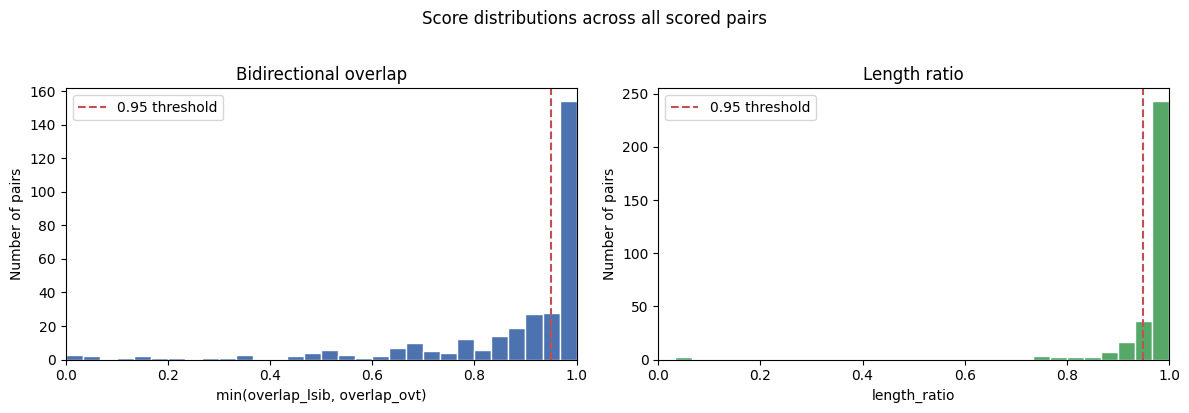

In [36]:
# Histograms of the two metrics, with the 0.95 match threshold marked
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bidirectional overlap (min of the two directions)
axes[0].hist(scored.overlap_min.dropna(), bins=30, range=(0, 1),
             color="#4c72b0", edgecolor="white")
axes[0].axvline(0.95, color="#c44e52", linestyle="--", linewidth=1.5, label="0.95 threshold")
axes[0].set_xlabel("min(overlap_lsib, overlap_ovt)")
axes[0].set_ylabel("Number of pairs")
axes[0].set_title("Bidirectional overlap")
axes[0].set_xlim(0, 1)
axes[0].legend()

# Right: length ratio
axes[1].hist(scored.length_ratio.dropna(), bins=30, range=(0, 1),
             color="#55a868", edgecolor="white")
axes[1].axvline(0.95, color="#c44e52", linestyle="--", linewidth=1.5, label="0.95 threshold")
axes[1].set_xlabel("length_ratio")
axes[1].set_ylabel("Number of pairs")
axes[1].set_title("Length ratio")
axes[1].set_xlim(0, 1)
axes[1].legend()

fig.suptitle("Score distributions across all scored pairs", y=1.02)
plt.tight_layout()
plt.show()


**What the histograms show.** Neither distribution is bimodal —
it's not "matches" cleanly separated from "non-matches." It's a long left tail.
Pairs in the high 0.95+ are clearly matches. Pairs below ~0.5 are clearly not.
The middle is where the work is.

So instead of one threshold, we use a **classification rule with three buckets**:

| Class | Rule | What it means |
|-------|------|---------------|
| `match` | both overlaps ≥ 0.95 AND length_ratio ≥ 0.95 | High agreement on path AND length |
| `geometric_disagreement` | length_ratio ≥ 0.95 AND overlap < 0.95 | Lengths agree, paths diverge |
| `review` | mid-range overlap (0.10 – 0.95) | Needs human judgment |
| `unmatched` | overlap < 0.10 either side | Effectively no spatial agreement |

*See the companion notes for why `geometric_disagreement` is the most
interesting class, and what it actually tells you when a pair lands there.*

In [37]:
def classify_match(row, match_thresh=0.95, length_thresh=0.95, floor=0.10):
    if pd.isna(row.overlap_lsib) or pd.isna(row.overlap_ovt):
        return "unmatched"
    both_overlap = min(row.overlap_lsib, row.overlap_ovt)
    if both_overlap < floor:
        return "unmatched"
    if both_overlap >= match_thresh and row.length_ratio >= length_thresh:
        return "match"
    if row.length_ratio >= length_thresh:
        return "geometric_disagreement"
    return "review"

scored["match_class"] = scored.apply(classify_match, axis=1)
print(scored.match_class.value_counts())


match_class
match                     169
geometric_disagreement    100
review                     45
unmatched                   5
Name: count, dtype: int64


## 8. Curated examples: what each class actually looks like

Bucket counts are abstract. The work of a crosswalk is in the cases. We've
picked six pairs that each tell a different story.

| Pair | Story | Class |
|------|-------|-------|
| **AR\|BR** | Clean match. Two datasets, same line. | `match` |
| **NO\|SE** | Clean match in one direction, asymmetry in the other. | `match` |
| **DE\|LU** | LSIB has 6.6 km of a ~135 km border. Coverage gap. | `unmatched` |
| **MY\|SG** | Overture has a 43-meter degenerate LineString. Data bug. | `unmatched` |
| **IN\|PK** | LSIB encodes International Boundary AND Line of Control as separate features. Overture merges them. | `review` |
| **KE\|SS** | Both sides fragmented. Ilemi Triangle dispute. | `both_fragmented` |


In [38]:
EXAMPLES = ["AR|BR", "NO|SE", "DE|LU", "MY|SG", "IN|PK", "KE|SS"]
examples_df = scored[scored.pair_key.isin(EXAMPLES)].set_index("pair_key").loc[EXAMPLES]
examples_df[["bucket", "match_class", "len_lsib_m", "len_ovt_m", "length_ratio", "overlap_lsib", "overlap_ovt"]]


,bucket,match_class,len_lsib_m,len_ovt_m,length_ratio,overlap_lsib,overlap_ovt
pair_key,,,,,,,
AR|BR,fragmented,match,1.282040e+06,1.287422e+06,0.995820,0.984609,0.979073
NO|SE,clean_1_to_1,match,1.910568e+06,1.854913e+06,0.970870,0.971018,1.000000
DE|LU,clean_1_to_1,unmatched,6.627805e+03,1.389564e+05,0.047697,1.000000,0.053010
MY|SG,clean_1_to_1,unmatched,8.291065e+04,4.368652e+01,0.000527,0.006549,1.000000
IN|PK,fragmented,geometric_disagreement,3.158016e+06,3.120645e+06,0.988166,0.919869,0.930455
KE|SS,both_fragmented,unmatched,3.105996e+05,4.212717e+05,0.737290,0.031459,0.022859


### Reading the examples

**AR|BR** — both overlaps near 0.98, length ratio 0.997. This is what
you want most pairs to look like.

**NO|SE** — both overlaps near 0.97, length ratio 0.97. Clean enough, but in a more in-depth exploration of this match this was a Hausdorff outlier (one bad vertex 49 km off,
on a 1,910 km boundary). The Hausdorff metric we cut from the demo would have
caught it. The lesson: **the metrics you choose determine the disagreements
you can find.**

**DE|LU** — `length_ratio` is 0.05. Five percent. LSIB has 6.6 km here; Overture
has ~138 km. The classifier lands this as `unmatched` because Overture's
overlap is only 5% (below our 10% floor). But the **reason** isn't a real
matching failure — it couls be a coverage gap on the LSIB side. This is the case
that shows why the `match_class` alone isn't enough: you need the metrics in
context. A downstream user looking at this row sees `unmatched`, then sees
`overlap_lsib_250m = 1.0` and `length_ratio = 0.05`, and reads it correctly
as "LSIB is fully inside Overture's buffer, but only covers 5% of the length."
That's a coverage gap, not a disagreement. Worth a divisions-team
conversation: what does LSIB do for the rest of the DE|LU border?

**MY|SG** — `length_ratio` is 0.0005. Half a thousandth. Overture has a 43-meter
LineString where it should have ~80 km of border between the Malaysia-Singapore
causeway and the Tuas crossing. That's a data bug in Overture. We can flag it and make sure we file it as a GitHub issue for Overture.

**IN|PK** — Overture has *more* line than LSIB, but the overlap on Overture's
side is only 0.69. LSIB is encoding the International Boundary (rank 1) as one
feature and the Line of Control (rank 2) as a separate feature. Overture merges
them into one. This is the "semantic vs. spatial" encoding asymmetry — both
datasets are "right," they're just answering different questions about what a
boundary is.

**KE|SS** — `both_fragmented`. Five rows on the LSIB side and Overture side
combined, and the fragmentation isn't random — it's the Ilemi Triangle, a
known disputed area. **When both datasets fragment a boundary, it's almost
always a known dispute.** This generalizes: the fact that two independent
datasets disagree about how to slice a border is itself a discovery signal
for contested geography.


## 9. Visual check on one example pair

A picture is the fastest way to understand a finding. Here's IN|PK plotted:
LSIB in red (under), Overture features colored on top.


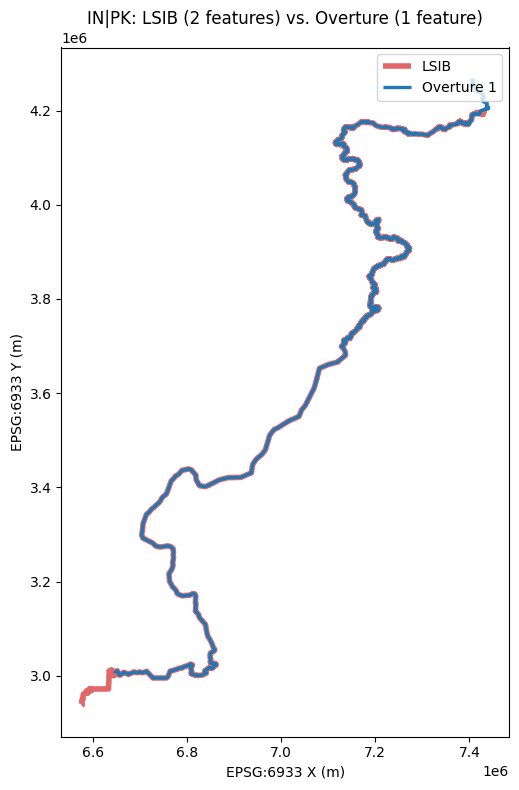

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

pk = "IN|PK"
lsib_pk = lsib_m[lsib_m.pair_key == pk]
ovt_pk = ovt_m[ovt_m.pair_key == pk]

# LSIB underneath, thicker, warm
lsib_pk.plot(ax=ax, color="#d62728", linewidth=4.0, alpha=0.7, label="LSIB", zorder=1)

# Overture on top, by feature
colors = ["#1f77b4", "#2ca02c", "#9467bd", "#ff7f0e"]
for i, (_, row) in enumerate(ovt_pk.iterrows()):
    gpd.GeoSeries([row.geometry], crs=METRIC_CRS).plot(
        ax=ax, color=colors[i % len(colors)], linewidth=2.4,
        label=f"Overture {i+1}", zorder=2
    )

ax.set_title(f"{pk}: LSIB ({len(lsib_pk)} feature{'s' if len(lsib_pk)>1 else ''}) vs. "
             f"Overture ({len(ovt_pk)} feature{'s' if len(ovt_pk)>1 else ''})")
ax.set_xlabel("EPSG:6933 X (m)")
ax.set_ylabel("EPSG:6933 Y (m)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


**What to point at on the IN|PK map.** LSIB has two features (rank 1 and
rank 2). Overture has one feature that traces the same overall corridor.

This static plot can't show you geographic context — no basemap, no zoom.
For an interactive view of this and the other example pairs, see the
GeoJSON export at the end of Section 10. Loaded into
[kepler.gl](https://kepler.gl), you can pan and zoom around Kashmir to
see where the LoC sits relative to the IB, with a proper map underneath.

## 10. Third decision point: the LSIB-to-GERS link table

This is the table we've been building toward. Each row connects one LSIB
segment ID to its corresponding Overture GERS ID, plus the metadata that
explains *how confident* the match is and *why* we classified it that way.

We're done matching. We have a classification per pair. What goes in the
output?

A crosswalk's core purpose is the ID-to-ID match. In principle, `(lsib_id, overture_id, match_score)` is enough — the metadata that describes each side already lives in the source datasets, and downstream users can join back to it through the IDs whenever they need to. Keeping the crosswalk minimal has real virtues: it's small, fast to read, and easy to version.
In this case we're going to include more than that anyway. The reason is the matching itself is likely to be iterated on — by us, by the divisions team, by anyone reviewing the output. Carrying the country pair, the bucket, the match class, and the metrics alongside each ID pair means a reviewer can read a row and see why it landed where it did without re-running the workflow. The metrics are part of the audit trail, not just inputs we discard.
So the schema we're writing has more columns than a strict crosswalk would. That's a deliberate choice tied to where this output sits in its lifecycle: it's a first draft for review, not a final published reference.

Schema choices we made:

- One row per (`lsib_id`, `overture_id`) pair. Either side can be null for unmatched rows.
- Both sides' identifiers preserved, plus the country pair, the bucket, the match class, and the metrics that produced the classification.
- Overture's `is_disputed` carried through. Useful filter for downstream consumers.
- LSIB's `RANK` carried through. Distinguishes international boundaries from lines of separation.

We're generating the table in two formats: Parquet and CSV.


In [40]:
# Build the output table from `scored` plus the unmatched rows
output_rows = []

for _, row in scored.iterrows():
    pk = row.pair_key
    lsib_rows = lsib[lsib.pair_key == pk]
    ovt_rows = ovt[ovt.pair_key == pk]
    cc_a, cc_b = pk.split("|")
    output_rows.append({
        "pair_key": pk,
        "country_a": cc_a,
        "country_b": cc_b,
        "bucket": row.bucket,
        "match_class": row.match_class,
        "lsib_id": ";".join(lsib_rows.ID.astype(str)) if len(lsib_rows) else None,
        "overture_id": ";".join(ovt_rows.id.astype(str)) if len(ovt_rows) else None,
        "lsib_rank_min": int(lsib_rows.RANK.min()) if len(lsib_rows) and lsib_rows.RANK.notna().any() else None,
        "lsib_length_m": row.len_lsib_m,
        "ovt_length_m": row.len_ovt_m,
        "length_ratio": row.length_ratio,
        "overlap_lsib_250m": row.overlap_lsib,
        "overlap_ovt_250m": row.overlap_ovt,
        "is_disputed": bool(ovt_rows.is_disputed.any()) if len(ovt_rows) else None,
    })

# Add lsib_only and overture_only rows
for _, row in pairs.iterrows():
    if row.bucket == "lsib_only":
        cc_a, cc_b = row.pair_key.split("|")
        lsib_rows = lsib[lsib.pair_key == row.pair_key]
        output_rows.append({
            "pair_key": row.pair_key, "country_a": cc_a, "country_b": cc_b,
            "bucket": "lsib_only", "match_class": "unmatched_lsib",
            "lsib_id": ";".join(lsib_rows.ID.astype(str)),
            "overture_id": None,
            "lsib_rank_min": int(lsib_rows.RANK.min()) if lsib_rows.RANK.notna().any() else None,
            "lsib_length_m": None, "ovt_length_m": None, "length_ratio": None,
            "overlap_lsib_250m": None, "overlap_ovt_250m": None, "is_disputed": None,
        })
    elif row.bucket == "overture_only":
        cc_a, cc_b = row.pair_key.split("|")
        ovt_rows = ovt[ovt.pair_key == row.pair_key]
        output_rows.append({
            "pair_key": row.pair_key, "country_a": cc_a, "country_b": cc_b,
            "bucket": "overture_only", "match_class": "unmatched_overture",
            "lsib_id": None,
            "overture_id": ";".join(ovt_rows.id.astype(str)),
            "lsib_rank_min": None,
            "lsib_length_m": None, "ovt_length_m": None, "length_ratio": None,
            "overlap_lsib_250m": None, "overlap_ovt_250m": None,
            "is_disputed": bool(ovt_rows.is_disputed.any()),
        })

crosswalk = pd.DataFrame(output_rows)
print(f"Crosswalk: {len(crosswalk):,} rows, {len(crosswalk.columns)} columns")
print()
print("match_class distribution:")
print(crosswalk.match_class.value_counts())


Crosswalk: 376 rows, 14 columns

match_class distribution:
match_class
match                     169
geometric_disagreement    100
review                     45
unmatched_lsib             38
unmatched_overture         19
unmatched                   5
Name: count, dtype: int64


In [41]:
# Write to Parquet and CSV
out_path_parquet = Path("./output/lsib_overture_crosswalk_demo.parquet")
out_path_csv = Path("./output/lsib_overture_crosswalk_demo.csv")
out_path_parquet.parent.mkdir(exist_ok=True)

crosswalk.to_parquet(out_path_parquet, index=False)
crosswalk.to_csv(out_path_csv, index=False)

print(f"Wrote {out_path_parquet} ({out_path_parquet.stat().st_size / 1024:.1f} KB)")
print(f"Wrote {out_path_csv} ({out_path_csv.stat().st_size / 1024:.1f} KB)")

# Read-back smoke test (Parquet)
check = pd.read_parquet(out_path_parquet)
assert len(check) == len(crosswalk)
print("Read-back OK.")

Wrote output/lsib_overture_crosswalk_demo.parquet (53.8 KB)
Wrote output/lsib_overture_crosswalk_demo.csv (71.5 KB)
Read-back OK.


### Export examples to GeoJSON for kepler.gl

The matplotlib plot in Section 9 is fine for a quick check, but it's not
interactive and it has no basemap context. To actually explore the geometry —
pan, zoom, toggle layers, see what's in the landscape around each boundary —
we'll export the six example pairs as GeoJSON and load them into
[kepler.gl](https://kepler.gl).

The export goes into one file (12 features: LSIB + Overture for each of 6
pairs). Each feature carries a `pair_key`, a `source` (`"lsib"` or
`"overture"`), and the `match_class` from the crosswalk we just built. In
kepler.gl, you can color or filter by any of these to recreate the per-pair
views.

In [42]:
# Export the six example pairs as a single GeoJSON for kepler.gl
# (https://kepler.gl) or any other GeoJSON-capable tool.

# Build a single GeoDataFrame with LSIB + Overture features for all six examples,
# tagged with pair_key, source, and the match_class from the crosswalk.

# Pull match_class per pair_key from the crosswalk we built in Section 10.
# (A pair_key can have multiple rows in the crosswalk if it's fragmented; we
# take the first match_class as a per-pair summary for the export.)
match_class_lookup = crosswalk.drop_duplicates("pair_key").set_index("pair_key")["match_class"].to_dict()

lsib_export = lsib[lsib.pair_key.isin(EXAMPLES)][["pair_key", "RANK", "geometry"]].copy()
lsib_export["source"] = "lsib"
lsib_export = lsib_export.rename(columns={"RANK": "rank"})
lsib_export["match_class"] = lsib_export.pair_key.map(match_class_lookup)

ovt_export = ovt[ovt.pair_key.isin(EXAMPLES)][["pair_key", "is_disputed", "geometry"]].copy()
ovt_export["source"] = "overture"
ovt_export["match_class"] = ovt_export.pair_key.map(match_class_lookup)

# Combine. Concat drops mismatched columns to NaN automatically.
combined = pd.concat([lsib_export, ovt_export], ignore_index=True)
combined = gpd.GeoDataFrame(combined, geometry="geometry", crs="EPSG:4326")

# Write as GeoJSON
out_path_geojson = Path("./output/lsib_overture_examples.geojson")
out_path_geojson.parent.mkdir(exist_ok=True)
combined.to_file(out_path_geojson, driver="GeoJSON")

print(f"Wrote {out_path_geojson} ({out_path_geojson.stat().st_size / 1024:.1f} KB)")
print(f"  {len(combined)} features across {combined.pair_key.nunique()} country pairs")
print(f"  Upload to kepler.gl, then filter or color by `pair_key`, `source`, or `match_class`.")


Wrote output/lsib_overture_examples.geojson (2735.6 KB)
  17 features across 6 country pairs
  Upload to kepler.gl, then filter or color by `pair_key`, `source`, or `match_class`.


## 11. Wrap-up: what we did, what's next

**What we did in this demo:**
1. Loaded LSIB v11.4 and Overture `division_boundary` (2026-04-15.0 release).
2. Filtered Overture to `is_land=true` to align with LSIB's land-only scope.
3. Bucketed every country pair by cardinality: `clean_1_to_1`,
   `fragmented`, `both_fragmented`, `lsib_only`, `overture_only`.
4. Computed bidirectional overlap at 250m and length ratio for every pair
   that has features on both sides.
5. Classified each pair into `match`, `geometric_disagreement`, `review`, or
   `unmatched` based on those metrics.
6. Walked through six example pairs that show what each kind of finding looks
   like in practice.
7. Wrote a crosswalk that preserves both sides' identifiers and metadata,
   not just a match score.

*See the companion notes for what a more complex version of this workflow
would add (multi-tolerance sweeps, Hausdorff, Hungarian assignment, sub-class
distinctions, geometry companion files).*

**Three things to take away:**
1. **The output is a link table, not a score.** Each row attaches a stable
   GERS ID to an LSIB segment. That linkage is what makes downstream work
   possible: tracking boundary changes across Overture releases, joining
   to other Overture themes, or bringing Overture's structural metadata
   into LSIB-based analysis.
2. **Building that table is iterative.** The `is_land` filter, the bucketing
   decision, the threshold choices — none of these are obvious before you
   look at the data, and all of them shape what your output means. Plan
   for re-runs and decision points, not a one-shot workflow.
3. **The disagreements are findings, not failures.** A pair that lands in
   `match` is confirmation. A pair in `geometric_disagreement` or `review`
   is a *finding* — something one of the datasets gets wrong, or something
   the two datasets are (correctly) saying different things about. Preserve
   both sides' metadata in the output so downstream users can read the
   findings in context.